# Avaliação de Modelos: RF vs Cluster-RF (HDBSCAN)

Compara dois modelos em **todos os datasets** com **ShuffleSplit (20 folds, test_size=0.3)**:

| Modelo | Estratégia de amostragem de features |
|--------|--------------------------------------|
| **RF (Sklearn)** | Uniforme — baseline |
| **Cluster-RF (HDBSCAN)** | 50/50 dentro/fora do cluster vencedor |

> O `onto_rf.py` precisa estar no mesmo diretório.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_curve, auc

from onto_rf import ClusterAwareRandomForestClassifier

## 1. Configuração Global

In [7]:
DATASETS = ["BLCA", "BRCA", "LIHC", "PRAD"]

# ── Validação Cruzada ─────────────────────────────────────────────────────────
N_SPLITS     = 50
TEST_SIZE    = 0.3
RANDOM_STATE = 42

# ── Parâmetros compartilhados dos modelos ─────────────────────────────────────
RF_PARAMS = dict(
    n_estimators=500,

    random_state=RANDOM_STATE,
    n_jobs=-1
)

print(f"Datasets: {DATASETS}")
print(f"ShuffleSplit: {N_SPLITS} folds, test_size={TEST_SIZE}")

Datasets: ['BLCA', 'BRCA', 'LIHC', 'PRAD']
ShuffleSplit: 50 folds, test_size=0.3


## 2. Validação Cruzada — Loop sobre todos os Datasets

Para cada dataset carrega:
- **mRNA** — expressão gênica (features)
- **Clusters HDBSCAN** — `data/output/clusters/genes_clustered_{DATASET}.csv`

In [8]:
all_results = {}
cv = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=TEST_SIZE, random_state=RANDOM_STATE)

for DATASET in DATASETS:
    print(f"\n{'='*60}")
    print(f"  Dataset: {DATASET}")
    print(f"{'='*60}")

    # ── Dados de Expressão ────────────────────────────────────────────────────
    mRNA_data     = pd.read_csv(f'data/input/deepkegg/{DATASET}_data/mRNA_data.csv')
    response_data = pd.read_csv(f'data/input/deepkegg/{DATASET}_data/response.csv')
    X_raw         = mRNA_data.drop(columns=['Case_ID'])
    y             = response_data['response'].values
    feature_names = list(X_raw.columns)
    print(f"  Shape: {X_raw.shape} | pos={sum(y==1)} neg={sum(y==0)}")

    # ── Clusters HDBSCAN ──────────────────────────────────────────────────────
    df_clusters  = pd.read_csv(f'data/output/clusters/genes_clustered_{DATASET}.csv')
    cluster_map  = df_clusters[['gene', 'cluster_hdbscan']]
    print(f"  Clusters HDBSCAN: {cluster_map['cluster_hdbscan'].nunique()} únicos (incl. ruído -1)")

    # ── Estrutura de métricas ─────────────────────────────────────────────────
    fpr_base = np.linspace(0, 1, 100)
    metrics = {
        'rf':      {'f1': [], 'auc': [], 'tpr': [], 'fpr_base': fpr_base},
        'cluster': {'f1': [], 'auc': [], 'tpr': []},
    }

    X_arr = X_raw.values

    for fold_i, (train_idx, test_idx) in enumerate(cv.split(X_arr, y)):
        X_tr_raw, X_te_raw = X_arr[train_idx], X_arr[test_idx]
        y_tr, y_te         = y[train_idx],     y[test_idx]

        scaler  = StandardScaler()
        X_tr    = scaler.fit_transform(X_tr_raw)
        X_te    = scaler.transform(X_te_raw)
        X_tr_df = pd.DataFrame(X_tr, columns=feature_names)
        X_te_df = pd.DataFrame(X_te, columns=feature_names)

        def _record(key, clf, X_test, y_true):
            preds = clf.predict(X_test)
            proba = clf.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_true, proba)
            metrics[key]['f1'].append(f1_score(y_true, preds, zero_division=0))
            metrics[key]['auc'].append(auc(fpr, tpr))
            metrics[key]['tpr'].append(np.interp(fpr_base, fpr, tpr))

        # ── 1. Random Forest padrão ───────────────────────────────────────────
        clf_std = RandomForestClassifier(**RF_PARAMS)
        clf_std.fit(X_tr, y_tr)
        _record('rf', clf_std, X_te, y_te)

        # ── 2. Cluster-RF (HDBSCAN) ───────────────────────────────────────────
        clf_cluster = ClusterAwareRandomForestClassifier(
            clusters=cluster_map, **RF_PARAMS
        )
        clf_cluster.fit(X_tr_df, y_tr)
        _record('cluster', clf_cluster, X_te_df, y_te)

        if (fold_i + 1) % 5 == 0:
            print(
                f"    fold {fold_i+1:2d}/{N_SPLITS} — "
                f"RF F1={metrics['rf']['f1'][-1]:.3f} AUC={metrics['rf']['auc'][-1]:.3f} | "
                f"Cluster-RF F1={metrics['cluster']['f1'][-1]:.3f} AUC={metrics['cluster']['auc'][-1]:.3f}"
            )

    # ── Resumo ────────────────────────────────────────────────────────────────
    print(f"\n  {'Modelo':<28} {'F1 (μ±σ)':>16} {'AUC (μ±σ)':>16}")
    print(f"  {'-'*62}")
    for label, key in [
        ("Random Forest (Sklearn)", 'rf'),
        ("Cluster-RF (HDBSCAN)",   'cluster'),
    ]:
        m = metrics[key]
        print(
            f"  {label:<28} "
            f"{np.mean(m['f1']):.4f}±{np.std(m['f1']):.4f}   "
            f"{np.mean(m['auc']):.4f}±{np.std(m['auc']):.4f}"
        )

    all_results[DATASET] = metrics

print(f"\n\n{'='*60}")
print("  Validação Cruzada Concluída para todos os datasets!")
print(f"{'='*60}")


  Dataset: BLCA
  Shape: (402, 1000) | pos=143 neg=259
  Clusters HDBSCAN: 331 únicos (incl. ruído -1)
    fold  5/50 — RF F1=0.400 AUC=0.623 | Cluster-RF F1=0.382 AUC=0.608
    fold 10/50 — RF F1=0.194 AUC=0.570 | Cluster-RF F1=0.197 AUC=0.591
    fold 15/50 — RF F1=0.300 AUC=0.624 | Cluster-RF F1=0.262 AUC=0.609
    fold 20/50 — RF F1=0.448 AUC=0.666 | Cluster-RF F1=0.375 AUC=0.675
    fold 25/50 — RF F1=0.348 AUC=0.571 | Cluster-RF F1=0.358 AUC=0.579
    fold 30/50 — RF F1=0.361 AUC=0.602 | Cluster-RF F1=0.328 AUC=0.563
    fold 35/50 — RF F1=0.214 AUC=0.653 | Cluster-RF F1=0.207 AUC=0.632
    fold 40/50 — RF F1=0.379 AUC=0.680 | Cluster-RF F1=0.393 AUC=0.682
    fold 45/50 — RF F1=0.276 AUC=0.682 | Cluster-RF F1=0.310 AUC=0.688
    fold 50/50 — RF F1=0.400 AUC=0.678 | Cluster-RF F1=0.419 AUC=0.668

  Modelo                               F1 (μ±σ)        AUC (μ±σ)
  --------------------------------------------------------------
  Random Forest (Sklearn)      0.3411±0.0659   0.6375±0

KeyboardInterrupt: 

## 3. Sumário Comparativo Final

In [9]:
rows = []
for ds, res in all_results.items():
    for label, key in [
        ("RF (Sklearn)",         'rf'),
        ("Cluster-RF (HDBSCAN)", 'cluster'),
    ]:
        m = res[key]
        rows.append({
            'Dataset': ds, 'Modelo': label,
            'F1 Média': np.mean(m['f1']),  'F1 Std':  np.std(m['f1']),
            'AUC Média': np.mean(m['auc']), 'AUC Std': np.std(m['auc']),
        })

df_summary = pd.DataFrame(rows).set_index(['Dataset', 'Modelo']).round(4)
display(df_summary)

F1 Média  F1 Std  AUC Média  AUC Std
Dataset Modelo                                                    
BLCA    RF (Sklearn)            0.3411  0.0659     0.6375   0.0448
        Cluster-RF (HDBSCAN)    0.3398  0.0598     0.6340   0.0451
BRCA    RF (Sklearn)            0.3916  0.1018     0.6795   0.0562
        Cluster-RF (HDBSCAN)    0.4124  0.0996     0.6756   0.0577
LIHC    RF (Sklearn)            0.5580  0.0446     0.6166   0.0364
        Cluster-RF (HDBSCAN)    0.5513  0.0413     0.6085   0.0376

## 4. Curvas ROC Médias por Dataset

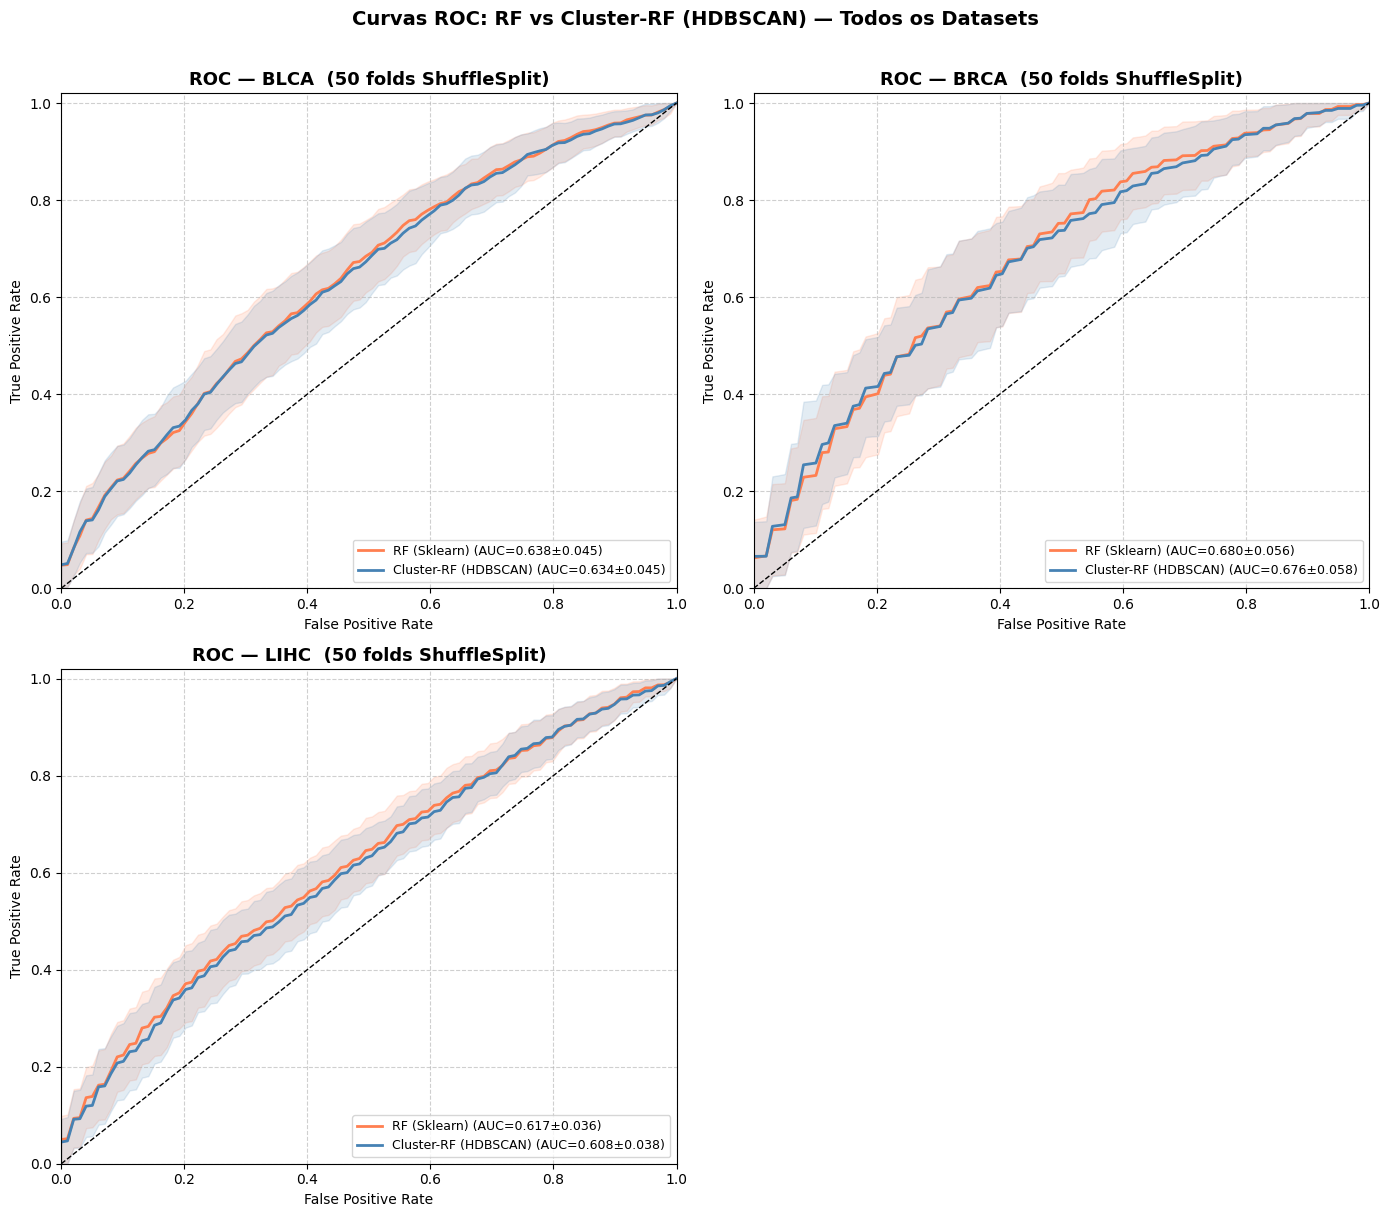

In [10]:
n_datasets = len(all_results)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

models_style = [
    ('rf',      'RF (Sklearn)',         'coral'),
    ('cluster', 'Cluster-RF (HDBSCAN)', 'steelblue'),
]

for ax_i, (ds, res) in enumerate(all_results.items()):
    ax = axes[ax_i]
    fpr_base = res['rf']['fpr_base']

    for key, name, color in models_style:
        m = res[key]
        mean_tpr = np.mean(m['tpr'], axis=0)
        std_tpr  = np.std(m['tpr'],  axis=0)
        mean_auc = np.mean(m['auc'])
        std_auc  = np.std(m['auc'])

        ax.plot(fpr_base, mean_tpr, color=color, linewidth=2,
                label=f"{name} (AUC={mean_auc:.3f}±{std_auc:.3f})")
        ax.fill_between(fpr_base,
                        np.clip(mean_tpr - std_tpr, 0, 1),
                        np.clip(mean_tpr + std_tpr, 0, 1),
                        color=color, alpha=0.15)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title(f"ROC — {ds}  ({N_SPLITS} folds ShuffleSplit)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

for ax_j in range(n_datasets, len(axes)):
    axes[ax_j].set_visible(False)

plt.suptitle('Curvas ROC: RF vs Cluster-RF (HDBSCAN) — Todos os Datasets',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()